# Postprocessing Code for ex_fit_ephemeris.cc


In [6]:
import pandas as pd
import pylupnt as pnt

In [7]:
# path to the data
planet = "MOON"
sim_min = 30
M0 = 0

eph_orders = [16, 20]

delta_r_diff = {}
delta_u_diff = {}
delta_i_diff = {}
delta_l_diff = {}

outdir = pnt.LUPNT_DATA_PATH + f"/../output/ex_ephemeris_fit"

for eph_order in eph_orders:
    data_dir = outdir + f"/{planet}/sim_{sim_min}_M0_{M0}/EPH{eph_order}"

    coeffs_delta = pd.read_csv(data_dir + "/coeffs_delta.csv")

    print(coeffs_delta.keys())

    RAD2ARCSEC = 206264.806247096355

    time = coeffs_delta["Time"].values
    delta_r_diff[eph_order] = (coeffs_delta["delta_r"] - coeffs_delta["delta_r_est"]).values * 1000
    delta_u_diff[eph_order] = (coeffs_delta["delta_u"] - coeffs_delta["delta_u_est"]).values * RAD2ARCSEC
    delta_i_diff[eph_order] = (coeffs_delta["delta_i"] - coeffs_delta["delta_i_est"]).values * RAD2ARCSEC
    delta_l_diff[eph_order] = (coeffs_delta["delta_omega"] - coeffs_delta["delta_omega_est"]).values * RAD2ARCSEC


Index(['Time', 'delta_r', 'delta_u', 'delta_i', 'delta_omega', 'delta_r_est',
       'delta_u_est', 'delta_i_est', 'delta_omega_est'],
      dtype='object')
Index(['Time', 'delta_r', 'delta_u', 'delta_i', 'delta_omega', 'delta_r_est',
       'delta_u_est', 'delta_i_est', 'delta_omega_est'],
      dtype='object')


<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_70650/2871380971.py:10: SyntaxWarning: invalid escape sequence '\D'
  labels = ["$\Delta \ r_k$ [m]", "$\Delta \ u_k$ [arcsec]", "$\Delta \ i_k$ [arcsec]", "$\Delta \ \lambda_k $  [arcsec]"]
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_70650/2871380971.py:10: SyntaxWarning: invalid escape sequence '\D'
  labels = ["$\Delta \ r_k$ [m]", "$\Delta \ u_k$ [arcsec]", "$\Delta \ i_k$ [arcsec]", "$\Delta \ \lambda_k $  [arcsec]"]
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_70650/2871380971.py:10: SyntaxWar

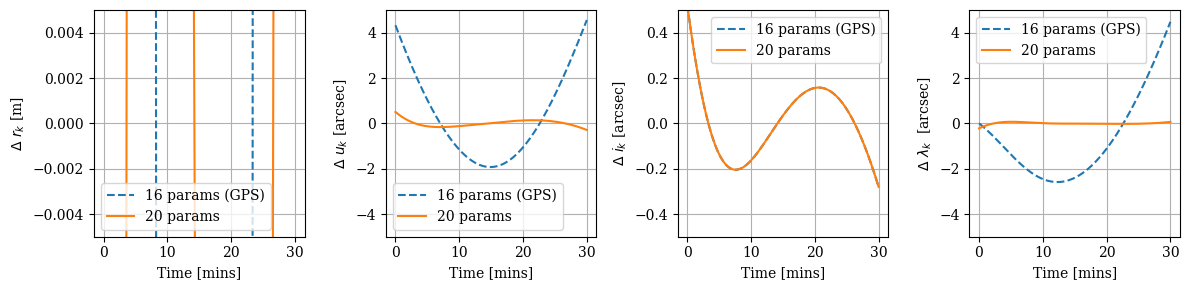

In [8]:
# plot the differences
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 3), sharex=True)
labels_eph = ["16 params (GPS)", "20 params"]
linestyles = ["--", "-"]

for i, eph_order in enumerate(eph_orders):
    data_eph = [delta_r_diff[eph_order], delta_u_diff[eph_order], delta_i_diff[eph_order], delta_l_diff[eph_order]]
    labels = ["$\Delta \ r_k$ [m]", "$\Delta \ u_k$ [arcsec]", "$\Delta \ i_k$ [arcsec]", "$\Delta \ \lambda_k $  [arcsec]"]
    ylim_abs = [5, 5, .5, 5]

    for ax, data_plot, label in zip(axs.flatten(), data_eph, labels):
        ax.plot(time/60, data_plot, linestyles[i], label=labels_eph[i])
        ax.legend()
        ax.set_xlabel("Time [mins]")
        ax.set_ylabel(label)
        ax.set_ylim([-ylim_abs[labels.index(label)], ylim_abs[labels.index(label)]])
        ax.grid(True)

plt.tight_layout()
plt.savefig(outdir + "/ephemeris_fit_diff_{}.pdf".format(planet))
plt.show()
